In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
# Set visualization style
plt.style.use('ggplot')
sns.set_palette("viridis")
print("Libraries imported successfully.")

Libraries imported successfully.


c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# --- Define File Paths ---
clinical_file = 'investigator_ftldlbd_nacc71.csv'
csf_file = 'investigator_fcsf_nacc71.csv'

# Check for files
if not os.path.exists(clinical_file) or not os.path.exists(csf_file):
    print(f"⚠️ ERROR: Files not found in {os.getcwd()}")
else:
    print("Files found. Loading...")

# 1. Load Clinical Data
df_clin = pd.read_csv(clinical_file)
cols_clin = ['NACCID', 'VISITYR', 'NACCUDSD', 'NACCAGE', 'NACCSEX', 'SEX', 'EDUC', 'NACCAPOE']
actual_cols_clin = [c for c in cols_clin if c in df_clin.columns]
df_clin = df_clin[actual_cols_clin].copy()

if 'SEX' in df_clin.columns:
    df_clin = df_clin.rename(columns={'SEX': 'NACCSEX'})
df_clin = df_clin.rename(columns={'VISITYR': 'YEAR'})

# 2. Load CSF Data
df_csf = pd.read_csv(csf_file)
cols_csf = ['NACCID', 'CSFABYR', 'CSFABETA', 'CSFPTAU', 'CSFTTAU']
df_csf = df_csf[cols_csf].copy()
df_csf = df_csf.rename(columns={'CSFABYR': 'YEAR'})

# 3. Merge (Clinical + CSF only)
df_final = pd.merge(df_clin, df_csf, on=['NACCID', 'YEAR'], how='inner')

print(f"Merged dataset shape: {df_final.shape}")

Files found. Loading...


C:\Users\user\AppData\Local\Temp\ipykernel_10544\221899735.py:12: DtypeWarning: Columns (20,22,24,26,28,41,44,46,48,51,61,63,65,67,69,71,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,134,156,165,176,179,189,217,220,222,224,226,228,230,232,234,236,238,240,242,244,246,248,250,252,254,256,258,260,262,264,266,268,270,272,382,397,399,401,419,421,423,432,445,454,494,574,605,613,638,674,690,704,707,710,715,727,738,744,746,804,809,810,811,812,820,831,833,835,837,843,904,959,960,961,969,970,971,972,982,1004,1007,1010,1029,1034,1204,1208,1211,1407,1409,1411,1412,1414,1421,1423,1425,1426,1433,1435,1437,1439,1440,1447,1462,1476,1490,1504,1506,1542,1558,1560,1562,1564,1566,1568,1570,1572,1574,1576,1578,1580,1582,1584,1586,1588,1590,1592,1594,1596,1598,1600,1602,1604,1606,1608,1610,1612,1662,1663,1665,1666,1669,1670,1673,1674,1677,1678,1681,1682,1756,1815,1824,1826,1828,1830,1841,1843,1845,1853,1855,1857,1859,1867,1869,1871,1873,1899) have mixed type

Merged dataset shape: (1892, 10)


In [4]:
# 1. Define Target (1=AD, 0=Normal)
df_model = df_final[df_final['NACCUDSD'].isin([1, 4])].copy()
df_model['target'] = df_model['NACCUDSD'].apply(lambda x: 1 if x == 4 else 0)

# 2. Handle Missing Values
features_check = ['CSFABETA', 'CSFPTAU', 'CSFTTAU', 'NACCAGE', 'EDUC']
df_model = df_model.dropna(subset=features_check)

# 3. Define X and y
drop_cols = ['NACCID', 'YEAR', 'NACCUDSD', 'target']
X = df_model.drop(columns=drop_cols, errors='ignore')
y = df_model['target']

print(f"Final samples: {X.shape[0]}")
print(f"Class Distribution:\n{y.value_counts()}")

Final samples: 1419
Class Distribution:
target
0    930
1    489
Name: count, dtype: int64


In [5]:
# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to DataFrame
feature_names = X.columns.tolist()
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

print("Data split and scaled.")

Data split and scaled.


In [6]:
print("Training multiple models for comparison...")

# 1. Random Forest (The reliable baseline)
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_train_df, y_train)

# 2. Gradient Boosting (Often the most accurate)
gb_model = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42
)
gb_model.fit(X_train_df, y_train)

# 3. SVM (Geometric approach - needs probability=True for ROC curves)
svm_model = SVC(
    kernel='rbf', C=1.0, probability=True, class_weight='balanced', random_state=42
)
svm_model.fit(X_train_df, y_train)

# 4. Logistic Regression (The simple linear baseline)
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
lr_model.fit(X_train_df, y_train)

print("✅ All models trained successfully.")

Training multiple models for comparison...
✅ All models trained successfully.


Model                | AUC Score 
-----------------------------------
Random Forest        | 0.9010
Gradient Boosting    | 0.8726
SVM (RBF Kernel)     | 0.8908
Logistic Regression  | 0.8631


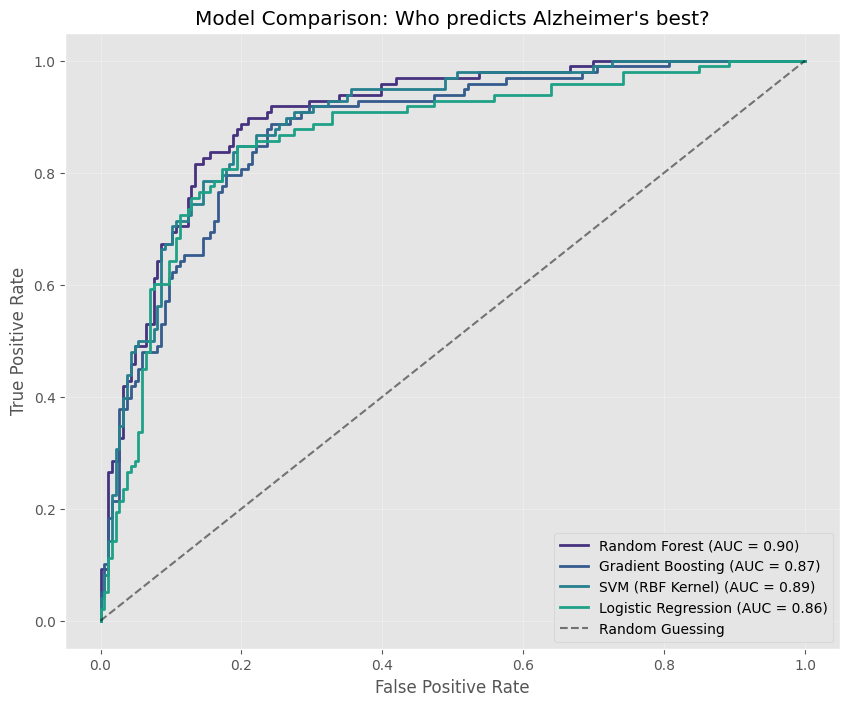

C:\Users\user\AppData\Local\Temp\ipykernel_10544\2137646235.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='Importance', y='Feature', palette='magma')


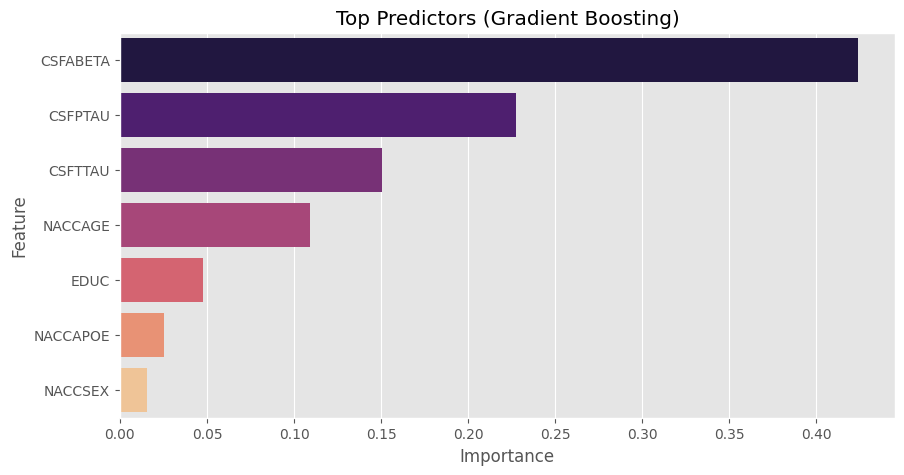

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve

# --- PLOT 1: ROC CURVES (Model Performance) ---
plt.figure(figsize=(10, 8))

print(f"{'Model':<20} | {'AUC Score':<10}")
print("-" * 35)

for name, model in models.items():
    # Get probabilities for the positive class
    y_prob = model.predict_proba(X_test_df)[:, 1]
    
    # Calculate AUC
    auc_score = roc_auc_score(y_test, y_prob)
    print(f"{name:<20} | {auc_score:.4f}")
    
    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})', linewidth=2)

# Add labels and legend to the FIRST plot
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Model Comparison: Who predicts Alzheimer\'s best?')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()  # <--- This finishes the first plot!


# --- PLOT 2: FEATURE IMPORTANCE (Interpretability) ---
# Now we start the second plot safely
importance = pd.DataFrame({
    'Feature': X_test_df.columns, 
    'Importance': gb_model.feature_importances_
})
importance = importance.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=importance, x='Importance', y='Feature', palette='magma')
plt.title("Top Predictors (Gradient Boosting)")
plt.show() # <--- This finishes the second plot!

Calculating SHAP values for Gradient Boosting...


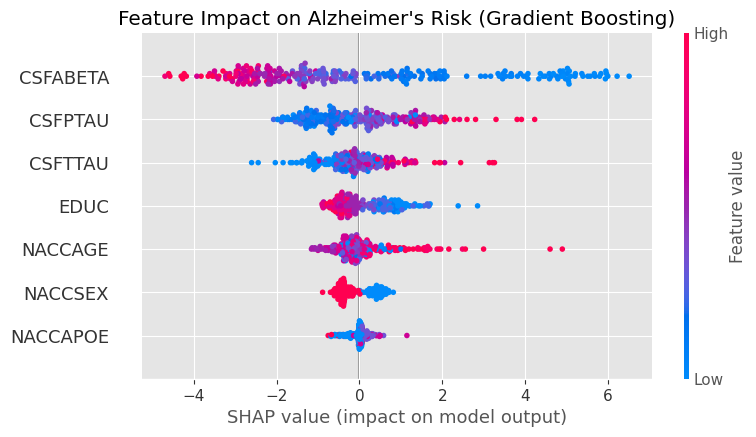

In [9]:
import shap  # <--- Make sure this is imported
import matplotlib.pyplot as plt

print("Calculating SHAP values for Gradient Boosting...")

# TreeExplainer works for both RF and Gradient Boosting
explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_test_df)

# Note: For Gradient Boosting, shap_values is usually a single array (unlike RF)
# We don't need to select an index [1] manually here usually, but let's check:
if isinstance(shap_values, list):
    shap_vals_plot = shap_values[1]
else:
    shap_vals_plot = shap_values

# --- PLOT SETUP ---
plt.figure()

# We add show=False so the plot doesn't display until we add our title
shap.summary_plot(shap_vals_plot, X_test_df, plot_type="dot", show=False)

plt.title("Feature Impact on Alzheimer's Risk (Gradient Boosting)")
plt.show()